In [137]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/src

/Users/arikreuter/Documents/PhD/CausalPriorFitting/src


In [138]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [139]:
from priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from priors.causal_prior.noise_distributions.MixedDist import MixedDist
from priors.causal_prior.scm.SCM import SCM
from priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from priors.causal_prior.mechanisms.BaseMechanism import BaseMechanism
from priors.causal_prior.mechanisms.IgnoreParentsMechanism import IgnoreParentsMechanism
from priors.causal_prior.noise_distributions.DistributionInterface import Distribution
from priors.causal_prior.noise_distributions.ResamplingDist import ResamplingDist
import torch

In [140]:
NUM_NODES = 50
p = 0.5 
SEED = 43
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
   num_nodes=NUM_NODES,
    p=p,
)

#new_edges = [(1, 2), 
#             #(1, 0), 
#             (0, 2)]
#graph.clear_edges()
#graph.add_edges_from(new_edges)



causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

# mechanisms 
mechanisms = {}
for node in causal_dag.nodes():
    # assign mechanisms
    mechanisms[node] = SampleMLPMechanism(
        input_dim=len(causal_dag.parents(node)),
        node_shape=(1,),  # scalar output

    )

# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = MixedDist(
        std = NOISE_STD
    )

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var] = MixedDist(
        std = NOISE_STD
    )



In [141]:
scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms = True
)



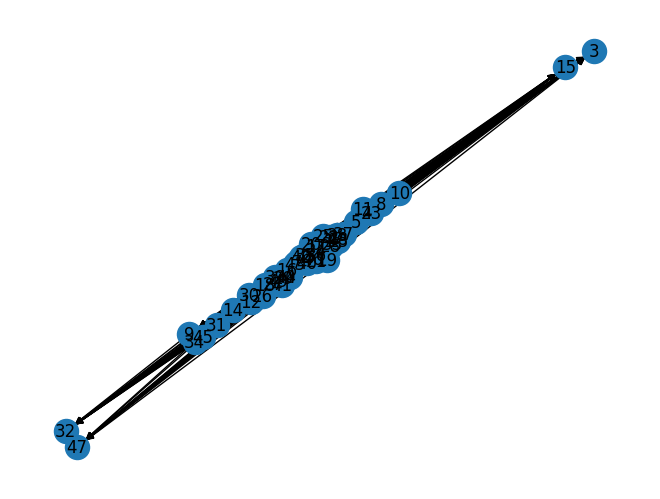

In [142]:
scm.dag.draw()

In [143]:
intervention_node = 0

In [144]:
#observational_sampling

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

obs0 = scm.propagate(num_samples=BATCH_SIZE)

In [145]:
obs0[intervention_node]

tensor([[-2.1632e-01],
        [-3.8209e-03],
        [ 3.0481e-02],
        [ 5.7056e-02],
        [ 6.1358e-02],
        [-2.2125e-01],
        [-4.8054e-02],
        [ 2.4119e-01],
        [ 7.6810e-02],
        [ 2.2084e-01],
        [-1.9179e-01],
        [-2.5648e-02],
        [ 1.0958e-01],
        [ 3.4048e-02],
        [ 2.7446e-02],
        [ 1.0435e-01],
        [-8.8358e-02],
        [ 5.2655e-03],
        [-1.0482e-01],
        [-1.4975e-02],
        [-1.6186e-01],
        [-1.1912e-01],
        [-1.3131e-02],
        [ 9.5807e-02],
        [ 1.4035e-01],
        [-2.7170e-02],
        [ 7.3509e-02],
        [-1.0033e-01],
        [-3.8937e-02],
        [-5.1245e-02],
        [ 1.0004e-01],
        [-7.6139e-02],
        [-3.1375e-02],
        [-3.3628e-02],
        [-1.4916e-01],
        [-1.1257e-01],
        [-4.5752e-04],
        [ 7.3465e-02],
        [ 8.8539e-02],
        [ 3.0999e-02],
        [-1.0248e-01],
        [-7.5003e-02],
        [-9.4652e-02],
        [ 1

In [146]:
intervention_samples

tensor([[-9.1675e-02],
        [-1.0825e-01],
        [ 1.8622e-02],
        [-8.1497e-02],
        [ 5.9022e-03],
        [-4.3758e-02],
        [ 1.7607e-01],
        [ 3.3975e-01],
        [-6.4306e-02],
        [-8.4645e-02],
        [ 2.7605e-03],
        [ 6.2940e-02],
        [-1.6731e-01],
        [-1.1198e-01],
        [ 8.3383e-02],
        [-7.5155e-02],
        [ 4.7241e-02],
        [ 1.4285e-02],
        [ 6.2121e-02],
        [ 1.3412e-01],
        [ 5.8375e-02],
        [ 1.7696e-01],
        [ 9.0733e-02],
        [ 4.6203e-04],
        [-1.2283e-01],
        [-1.5373e-01],
        [ 1.0022e-01],
        [ 1.9912e-02],
        [ 6.8940e-02],
        [-1.7067e-01],
        [-1.6146e-01],
        [ 7.9947e-02],
        [-6.1813e-02],
        [-2.8611e-03],
        [ 3.4430e-02],
        [ 1.2239e-02],
        [-1.0260e-02],
        [ 1.0742e-02],
        [ 2.7038e-02],
        [-1.5216e-01],
        [-1.0263e-01],
        [-5.8308e-02],
        [-1.4256e-01],
        [-3

In [147]:
# for interventional sampling, first determine intervention node

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

obs1 = scm.propagate(num_samples=BATCH_SIZE) #sample observational data again. 

intervention_samples = obs1[intervention_node] # collect set of observational samples for the intervention node

interventional_dist = ResamplingDist(intervention_samples) # create resampling distribution based on observational samples for the intervention node


scm.intervene(intervention_node)

if intervention_node in scm.dag.endogenous_variables():
    scm.endogenous_noise[intervention_node] = interventional_dist

if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist


scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

interv1 = scm.propagate(num_samples=BATCH_SIZE)


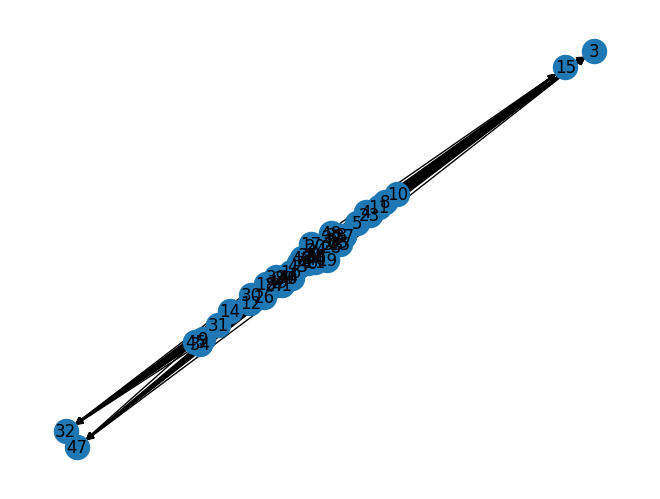

In [148]:
scm.dag.draw()

In [149]:
intervention_samples

tensor([[ 2.0241e-02],
        [ 5.4469e-02],
        [ 1.9454e-01],
        [ 2.5004e-01],
        [ 1.1998e-02],
        [-1.1475e-02],
        [-9.7629e-03],
        [-7.2524e-02],
        [ 3.1125e-02],
        [ 2.0735e-02],
        [ 5.1967e-02],
        [-4.9608e-02],
        [-7.7764e-02],
        [-1.8618e-02],
        [-7.3313e-02],
        [-2.6140e-01],
        [-5.1714e-02],
        [-4.5115e-02],
        [ 4.6611e-02],
        [-1.0498e-01],
        [ 6.5005e-03],
        [ 2.2335e-01],
        [ 7.6426e-03],
        [-9.7712e-02],
        [ 1.5701e-02],
        [-1.8805e-02],
        [-7.3479e-02],
        [-2.9686e-02],
        [-1.5649e-02],
        [ 4.5179e-02],
        [ 8.2753e-02],
        [-1.6963e-02],
        [ 5.5913e-02],
        [-2.2062e-02],
        [-2.0385e-02],
        [ 3.7894e-02],
        [-3.5958e-02],
        [ 1.2192e-01],
        [ 2.7658e-01],
        [-1.1475e-01],
        [-5.7991e-02],
        [ 4.2303e-02],
        [ 1.2029e-01],
        [ 1

In [150]:
interventional_dist.sample_n(100)

tensor([-0.0629, -0.0486,  0.1449,  0.0013,  0.1187,  0.0839, -0.0447,  0.0678,
        -0.0177,  0.0419, -0.0763, -0.1228,  0.0505, -0.0179,  0.0583,  0.0718,
        -0.0115,  0.0240,  0.1304, -0.0065, -0.0930, -0.0115,  0.0522,  0.0870,
         0.0839, -0.0478, -0.1292, -0.1328,  0.1207, -0.1053, -0.0466,  0.0572,
        -0.1423, -0.0367, -0.0246, -0.2275, -0.0860, -0.0093,  0.0519, -0.0342,
        -0.0039,  0.0926, -0.0960,  0.2087,  0.1521,  0.1668,  0.0146,  0.0814,
        -0.0048,  0.0166,  0.2233,  0.0256,  0.1313,  0.0741,  0.0862, -0.1253,
        -0.0591, -0.2221,  0.0202,  0.3142, -0.0144,  0.0378,  0.0541, -0.1887,
         0.0507,  0.0703, -0.0647,  0.2306,  0.0719, -0.0642,  0.1428, -0.0860,
         0.0434,  0.0058, -0.0478,  0.0520, -0.0294,  0.1337, -0.0996, -0.0417,
        -0.0778, -0.1312, -0.0237, -0.0719, -0.0564,  0.0260,  0.0014,  0.0665,
        -0.0794, -0.5254,  0.0529,  0.0913, -0.0408, -0.1002,  0.0693,  0.0828,
        -0.0904,  0.0664, -0.0264, -0.16

In [151]:
interv1[intervention_node]

tensor([[-2.9997e-02],
        [-2.1522e-01],
        [-3.6647e-02],
        [-2.9028e-03],
        [ 6.5138e-02],
        [-3.4172e-01],
        [-5.2013e-02],
        [-4.7707e-02],
        [-3.3174e-02],
        [-1.7705e-02],
        [ 6.1504e-02],
        [-2.9716e-02],
        [ 1.4317e-03],
        [-2.0211e-02],
        [-3.7190e-02],
        [ 3.7894e-02],
        [-1.3116e-01],
        [-1.1377e-01],
        [ 2.1401e-02],
        [ 1.3102e-01],
        [-1.0277e-03],
        [ 1.1394e-01],
        [ 6.1890e-01],
        [ 4.3817e-03],
        [-1.5351e-01],
        [ 3.4768e-01],
        [-1.1791e-01],
        [-6.9999e-02],
        [ 3.2335e-02],
        [ 3.5315e-02],
        [-9.7748e-03],
        [-3.3080e-02],
        [ 1.8638e-03],
        [-1.9805e-02],
        [ 4.2303e-02],
        [-9.5890e-02],
        [-1.3032e-02],
        [-5.4862e-02],
        [ 7.0231e-03],
        [ 2.5460e-01],
        [-1.2430e-01],
        [-5.3276e-02],
        [-3.1661e-02],
        [-2